In [ ]:
using Gen, Plots, Random

# Model Definition
@gen function multi_armed_bandit_model(
    success_prior::Vector{Float64},
    fail_prior::Vector{Float64},
    n_pulls_per_arm::Vector{Int}
)
    n_arms = length(success_prior)
    theta = [@trace(Gen.beta(success_prior[i], fail_prior[i]), (:theta, i)) for i in 1:n_arms] # Calculate theta for arm
    
    for i in 1:n_arms
        @trace(binom(n_pulls_per_arm[i], theta[i]), (:obs, i)) # Observation for arm i and theta i
    end
    
    return theta
end

# Inference
function do_inference(model, args, observations, num_samples)
    (traces, log_weights, _) = Gen.importance_sampling(
        model,
        args,
        observations,
        num_samples
    )
    weights = exp.(log_weights)
    return traces, weights
end

# Plotting Function
function plot_posteriors(traces, weights, n_arms)
    theta_samples = [
        [tr[(:theta, i)] for tr in traces] 
        for i in 1:n_arms
    ]
    
    plots = []
    for i in 1:n_arms
        # Normalize weights for plotting
        normalized_weights = weights ./ sum(weights)
        p = histogram(theta_samples[i], weights=normalized_weights, bins=20,
            title="Arm $i Posterior", xlabel="θ_$i", 
            legend=false, xlims=(0, 1))
        push!(plots, p)
    end
    
    plot(plots..., layout=(n_arms, 1), size=(600, 800))
end

plot_posteriors (generic function with 1 method)

Posterior means:
Arm 1: 0.164
Arm 2: 0.333


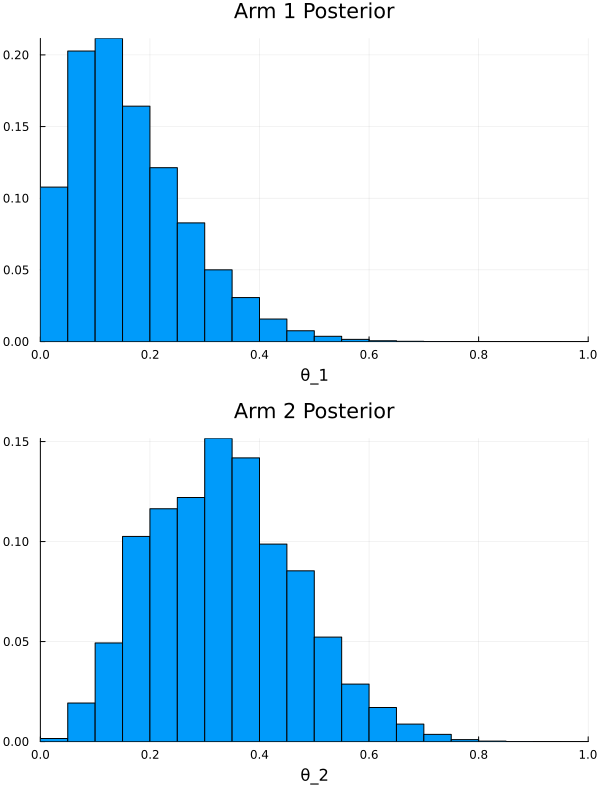

In [9]:

# Parameters
n_pulls_per_arm = [10, 10]  # Each arm pulled 10 times
prior_success = [1.0, 1.0]  # Beta(1,1) prior for both arms
prior_fail = [1.0, 1.0]
n_arms = 2

# Model arguments (success_prior, fail_prior, n_pulls_per_arm)
model_args = (prior_success, prior_fail, n_pulls_per_arm)

# Observed data: 1 success out of 10 for arm 1, 3 out of 10 for arm 2
observations = choicemap()
observations[(:obs, 1)] = 1  # Arm 1 successes
observations[(:obs, 2)] = 3  # Arm 2 successes

# Run inference
traces, weights = do_inference(
    multi_armed_bandit_model,
    model_args,
    observations,
    10000
)

# Calculate posterior means
posterior_means = [
    sum([tr[(:theta, i)] * w for (tr, w) in zip(traces, weights)]) / sum(weights)
    for i in 1:n_arms
]

println("Posterior means:")
for (i, mean) in enumerate(posterior_means)
    println("Arm $i: $(round(mean, digits=3))")
end

# Plot posteriors
plot_posteriors(traces, weights, n_arms)